In [1]:
import os 
import glob 
import numpy as np
import cv2 
from PIL import Image
from pathlib import Path
from itertools import groupby
import glob
from skimage import io
import random 
import matplotlib.pyplot as plt
%matplotlib inline

# Exploring Data (area_5a/data)
## Unzip data_area5a.zip in data/raw

In [20]:
# Function to Get all the file names (paths) for loading

def get_filenames():
    
    rgb=[]
    scene_=[]
    i = np.random.sample()
    for path in glob.glob('../data/rgb/*.png'):
        pth=str(Path(path))
        s = pth.split('_')
        ss = s[2:5]
        ss=''.join(ss)
        if ss not in scene_:
            scene_.append(ss)
        rgb.append(pth)
    return rgb, scene_

# Found 3 main Scenes in this data directory



    

In [21]:
# Calling get_filenames function 
rgb_files, scene_ = get_filenames()

off=sorted([i for i in scene_ if 'office' in i]) # office
hall=sorted([i for i in scene_ if 'hallway' in i]) # Hallway
lobby=sorted([i for i in scene_ if 'lobby' in i]) # Lobby

In [17]:
# Reading images from area_5a/data directory
# RGB images, Depth, and Semantics are shown 
# This function will be modified later and included as a method to get item in dataste loader 
# N=int(input())

def __getitem__(N):
#     rgb_imgs = np.zeros((N, 480, 640, 3), dtype=np.float32)
#     depth_imgs = np.zeros((N,  480, 640), dtype=np.float32)
#     label_imgs = np.zeros((N, 480, 640,3), dtype=np.uint8)

    for i in range(N):
        
        for j, filename in enumerate(rgb_files):
            pth = filename
            dpth=pth.replace('rgb','depth')
            lbls = pth.replace('rgb','semantic')

            # RGB

            rgb_img =cv2.cvtColor(cv2.imread(pth), cv2.COLOR_BGR2RGB)
            rgb_file = ''.join(pth.split('_')[2:6])
            print(f'RGB Image {rgb_file} with Size {rgb_img.shape} and dtype {rgb_img.dtype} ')
            # Resize image to 480*640
            rgb_ = cv2.resize(rgb_img, dsize=(640, 480), interpolation=cv2.INTER_AREA)
            print(f'RGB Resized from {rgb_img.shape} to {rgb_.shape}')
            
            depth_img = cv2.imread(dpth, cv2.IMREAD_ANYDEPTH)
            depth_file= ''.join(dpth.split('_')[2:6])
            print(f'Depth Image {depth_file} with Size {dimg.shape} and dtype {dimg.dtype}')
             # Resize image to 480*640
            depth_ = cv2.resize(depth_img, dsize=(640, 480), interpolation=cv2.INTER_AREA)
            print(f'Depth Image Resized from {depth_img.shape} to {depth_.shape}')

            lbl_img =cv2.imread(lbls)
            lbl_file = ''.join(lbls.split('_')[2:6])
            print(f'Semantic Image {lbl_file} with Size {lbl_img.shape} and dtype {lbl_img.dtype}')
             # Resize image to 480*640
            label_ = cv2.resize(lbl_img, dsize=(640, 480), interpolation=cv2.INTER_AREA)
            print(f'Semantic Image Resized from {lbl_img.shape} to {label_.shape}')
            
            if j == i:
                break
                
        batch = {'rgb':[rgb_img,rgb_],
                         'depth':[depth_img,depth_],
                         'Label':[lbl_img,label_]
                   }
        return batch


In [261]:
batch['rgb'][0].shape

(1080, 1080, 3)

In [260]:
batch['rgb'][1].shape

(480, 640, 3)

C:\Users\Mustafa\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:20: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.


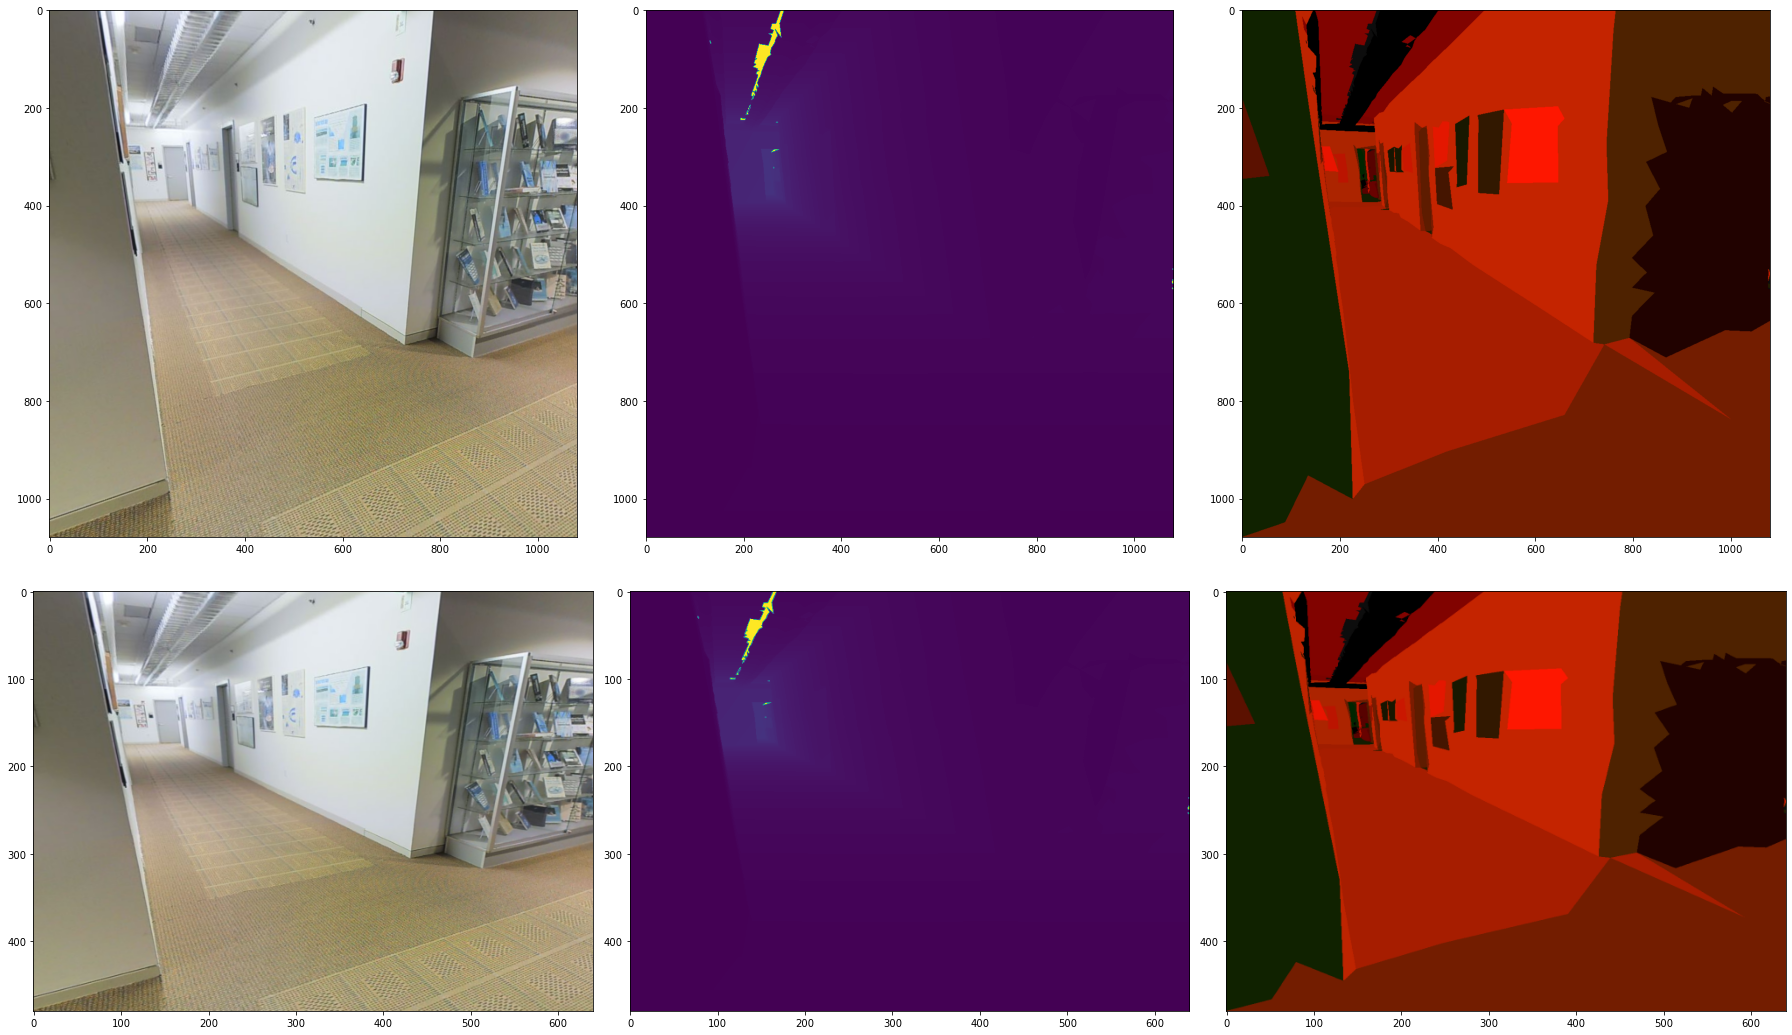

In [279]:
fig, axs = plt.subplots(2,3)
plt.rcParams["figure.figsize"] = [25, 8]
plt.rcParams["figure.autolayout"] = True

for i in range (2):
    rgb= batch['rgb']
    depth = batch['depth']
    semantic = batch['Label']
    
    
#     img=[rgb, depth,labels] 
    
    axs[i,0].imshow(rgb[i])
#     axs[i,0].axis('off')
    axs[i,1].imshow(depth[i])
#     axs[i,1].axis('off')
    axs[i,2].imshow(semantic[i])
#     axs[i,2].axis('off')
        
fig.show()

C:\Users\Mustafa\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:21: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.


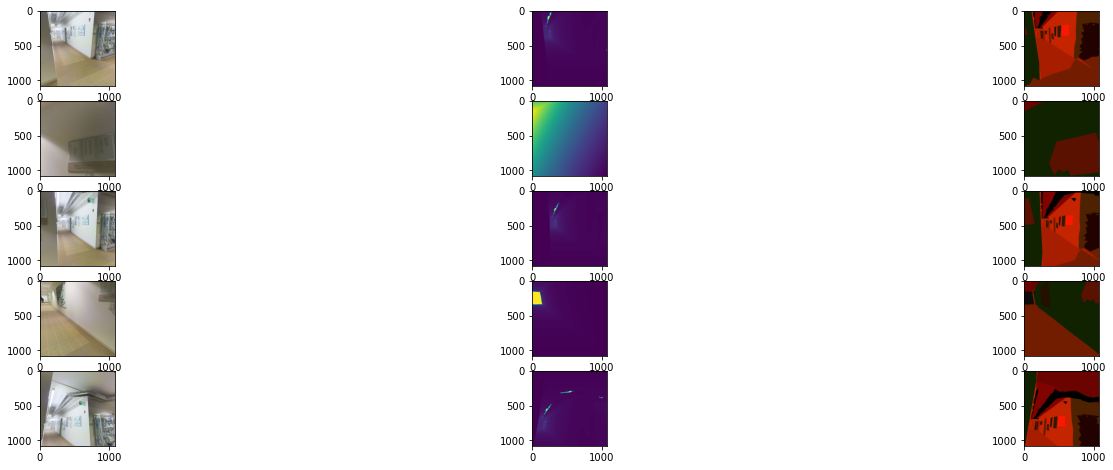

In [278]:
fig, axs = plt.subplots(5,3)
plt.rcParams["figure.figsize"] = [25, 15]
plt.rcParams["figure.autolayout"] = True

for i in range (5):
    rgb= images['rgb'].astype(np.uint8)
    depth = images['depth'].astype(np.float32)
    semantic = images['Semantic']
    
    
#     img=[rgb, depth,labels] 
    
    axs[i,0].imshow(rgb[i])
#     axs[i,0]
#     axs[i,0].axis('off')
    axs[i,1].imshow(depth[i])
#     axs[i,1].axis('off')
    axs[i,2].imshow(semantic[i])
#     axs[i,2].axis('off')
        
fig.show()